In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

In [4]:
notebook_path = Path.cwd()
base_path = notebook_path.parents[0]

raw_path = base_path / "data" / "raw" 
processed_path = base_path / "data" / "processed" 
plot_path = base_path / "fig"

In [5]:
df = pd.read_csv(processed_path / "seive_percentage.csv")

df["year_month"] = pd.to_datetime(
    df["month"] + " " + df["year"].astype(str)
).dt.to_period("M")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\LENOVO\\Documents\\Abundance_Biomass\\abundance_biomass\\code\\data\\processed\\seive_percentage.csv'

In [4]:
grain_labels = {
    'sieve_2mm_perc': 'Very coarse sand',
    'sieve_1mm_perc': 'Coarse sand',
    'sieve_500um_perc': 'Medium sand',
    'sieve_250um_perc': 'Fine sand',
    'sieve_125um_perc': 'Very fine sand',
    'sieve_63um_perc': 'Coarse silt',
    'sieve_pan_perc': 'Medium–very fine silt / clay (<63 µm)'
}

df = df.rename(columns=grain_labels)
site_means = df.groupby('site')[list(grain_labels.values())].mean()

colors = [
    '#ff5733',  # bright orange-red
    '#ff8d1a',  # orange
    '#ffd133',  # yellow
    '#75c34d',  # green
    '#3498db',  # blue
    '#9b59b6',  # purple
    '#e84393'   # pink
]

<Figure size 1200x600 with 0 Axes>

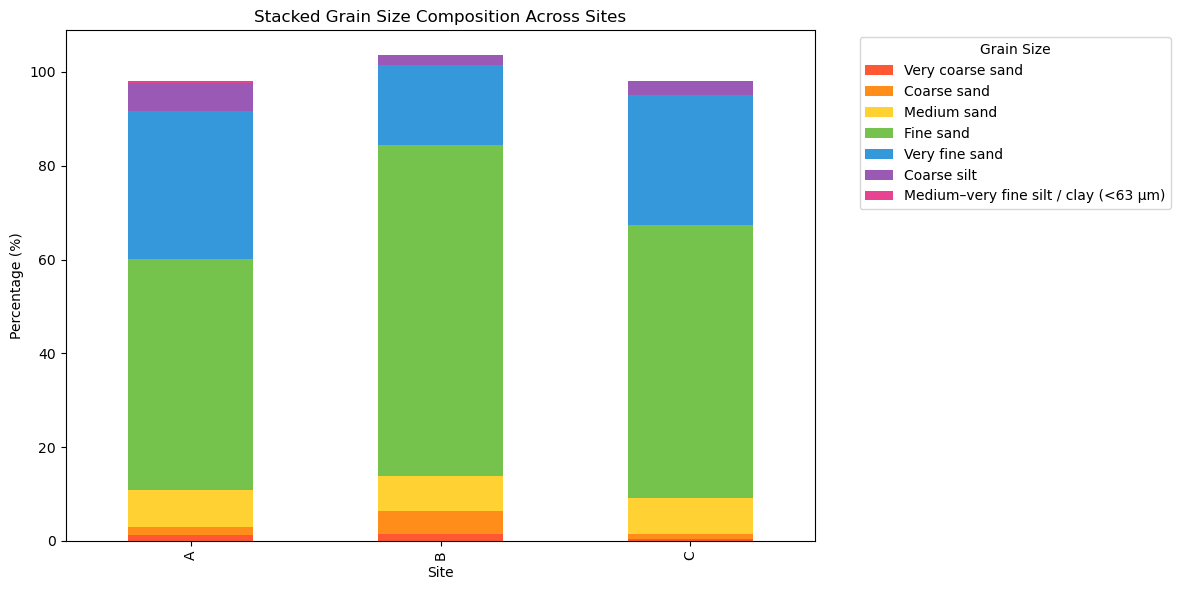

In [5]:
plt.figure(figsize=(12, 6))
ax = site_means.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(12, 6)
)

ax.set_xlabel("Site")
ax.set_ylabel("Percentage (%)")
ax.set_title("Stacked Grain Size Composition Across Sites")

# Move legend outside plot
plt.legend(
    title="Grain Size",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.savefig(plot_path / "stacked_bar.png", dpi=300)
plt.show()

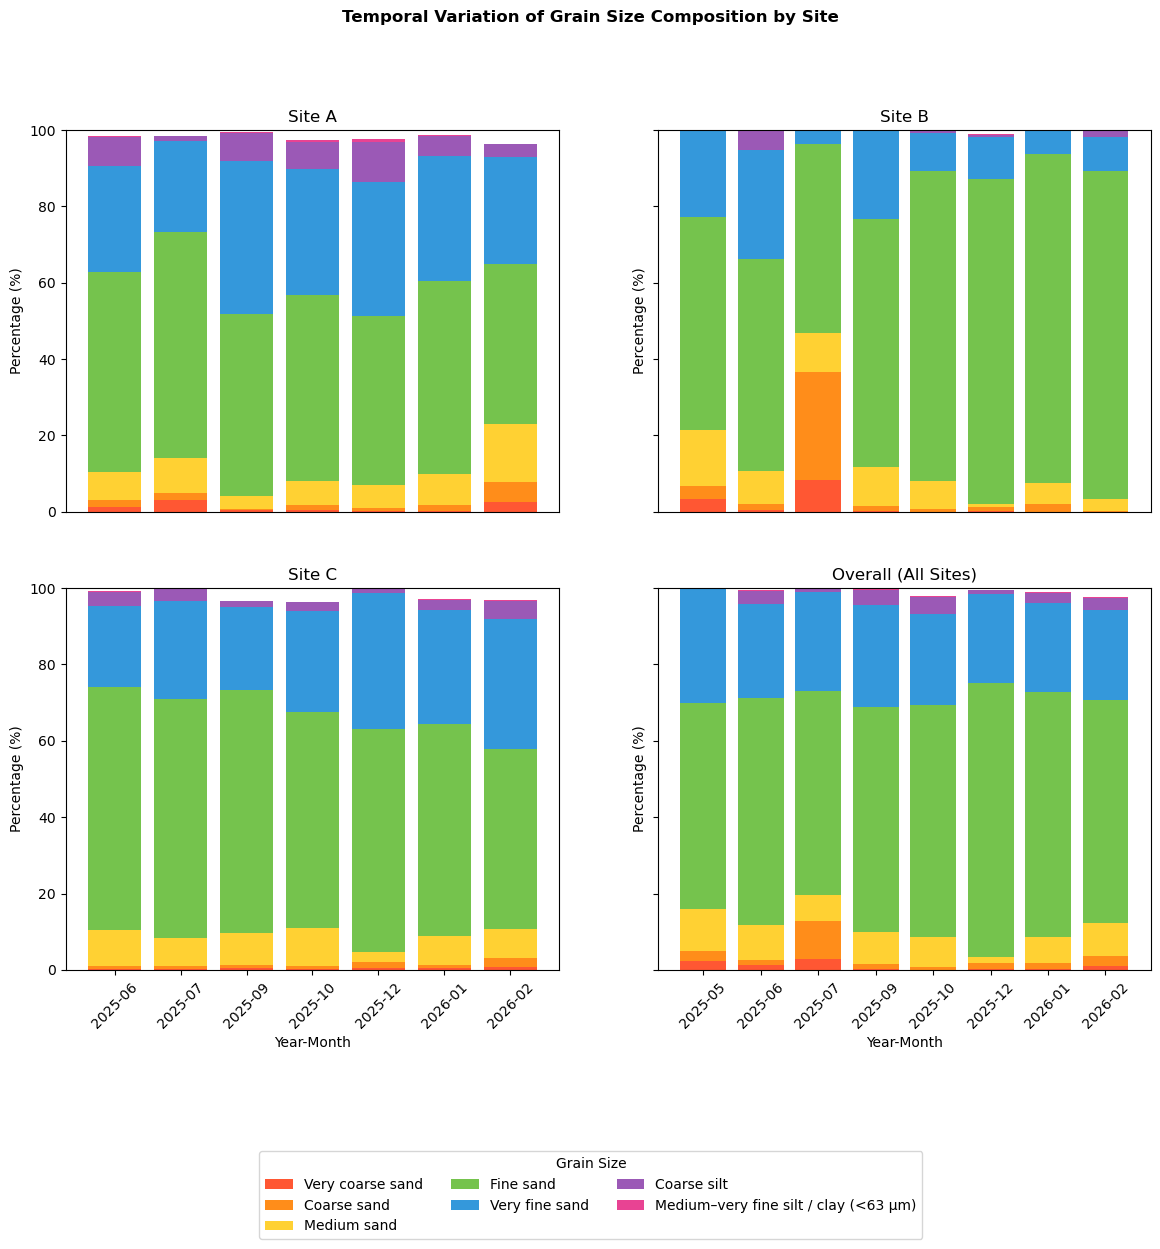

In [6]:
# Sites
sites = df['site'].unique()

fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharey=True)
axes = axes.flatten()

# Compute means
site_month_means = (
    df.groupby(['site', 'year_month'])[list(grain_labels.values())]
      .mean()
      .reset_index()
)

overall_month_means = (
    df.groupby('year_month')[list(grain_labels.values())]
      .mean()
      .reset_index()
)

site_month_means["year_month"] = site_month_means["year_month"].astype(str)
overall_month_means["year_month"] = overall_month_means["year_month"].astype(str)

# Plot first 3 site subplots only
for i, site in enumerate(sites[:3]):
    ax = axes[i]

    data = (
        site_month_means[site_month_means['site'] == site]
        .set_index('year_month')
    )

    bottom = pd.Series(0, index=data.index)

    for col, color in zip(grain_labels.values(), colors):
        ax.bar(data.index, data[col], bottom=bottom, color=color)
        bottom += data[col]

    ax.set_title(f"Site {site}")
    ax.set_ylim(0, 100)
    ax.set_ylabel("Percentage (%)")

    # only bottom-left subplot gets x-axis labels
    if i == 2:
        ax.set_xlabel("Year-Month")
        ax.tick_params(axis='x', rotation=45)
    else:
        ax.tick_params(axis='x', bottom=False, labelbottom=False)

# Bottom-right subplot = overall
ax = axes[3]

data = overall_month_means.set_index('year_month')
bottom = pd.Series(0, index=data.index)

for col, color in zip(grain_labels.values(), colors):
    ax.bar(data.index, data[col], bottom=bottom, color=color)
    bottom += data[col]

ax.set_title("Overall (All Sites)")
ax.set_ylim(0, 100)
ax.set_ylabel("Percentage (%)")
ax.set_xlabel("Year-Month")
ax.tick_params(axis='x', rotation=45)

fig.suptitle("Temporal Variation of Grain Size Composition by Site", weight='bold')

fig.legend(
    labels=list(grain_labels.values()),
    loc='lower center',
    ncol=3,
    bbox_to_anchor=(0.5, -0.05),
    title="Grain Size"
)

fig.subplots_adjust(bottom=0.18)
plt.savefig("grain_size_composition.png", dpi=300, bbox_inches='tight')
plt.show()